In [1]:
%matplotlib inline
%run -i setupMatplotlib.py

In [2]:
import os

projectDir = os.environ['PLATO_PROJECT_HOME']
workDir = os.environ['PLATO_WORKDIR']

%run -i setupEnvironment.py

In [3]:
import numpy as np

In [4]:
from imp import reload
import simfile
reload(simfile)
from simfile import SimFile
import simulation
reload(simulation)
from simulation import Simulation

In [5]:
sim = Simulation("Run01", outputDir = workDir)
sim["PSF/Model"] = "MappedFromFileSymmetrical"
sim.run(removeOutputFile = True)
simFile = SimFile(workDir + '/Run01.hdf5')

### API of SimFile

Request image, bias and smearing maps
```
img = simFile.getImage(<Exposure Nr>)
biasMapLeft = simFile.getBiasMapLeft(<Exposure Nr>)
biasMapRight = simFile.getBiasMapRight(<Exposure Nr>)
smearingMap = simFile.getSmearingMap(<Exposure Nr>)

subPixelImage = simFile.getSubPixelImage(<Exposure Nr>)
```

Request smaller imagettes around a star position
```
im = simFile.getImagette(11632, 9, radius = 3)
```

Request star information
```
starIDs, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = simFile.getStarCatalog()
ID, row, col, Xmm, Ymm = simFile.getStarCoordinates(<Exposure Nr> [, minVmag=<Vmag>, maxVmag=<Vmag>])
```

Request Input Parameters
```
value = simFifle.getInputParameter(<groupName>, <parameterName>)
```

Request the Flatfield maps
```
prnu = simFile.getPRNU()
irnu = simFile.getIRNU()
```

Request the PSF
```
psf = simFile.getPsf("rebinnedPSFimage")
```

Request Platform information
```
RA, dec = simFile.getPlatformPointingCoordinates()
yaw, pitch, roll = simFile.getYawPitchRoll()
```

Reloading the HDF5 file
```
simFile.reload()
```

In [6]:
img0 = simFile.getImage(0)

In [7]:
bm0 = simFile.getBiasMapLeft(0)
sm0 = simFile.getSmearingMap(0)

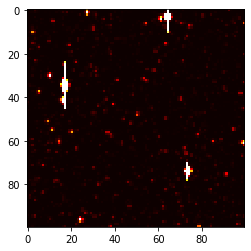

In [8]:
plt.imshow(img0, cmap=cm.hot)

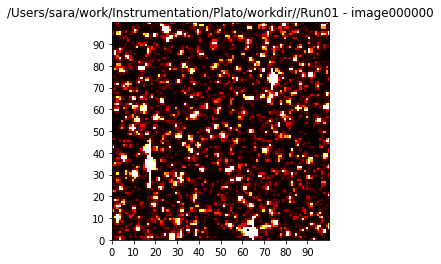

In [9]:
simFile.showImage(0)

In [10]:
#subPixelImage = simFile.getSubPixelImage(9)

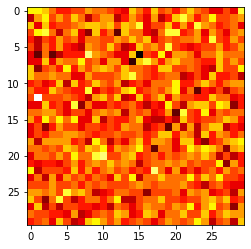

In [11]:
plt.imshow(bm0, interpolation='nearest', cmap=cm.hot)

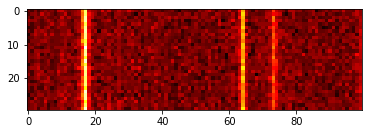

In [12]:
plt.imshow(sm0, interpolation='nearest', cmap=cm.hot)

In [13]:
starIDs = simFile.getStarCoordinates(9, minVmag = None, maxVmag = None)[0]
print(starIDs)

[13164 13181 13200 ... 23926 23928 23932]


In [14]:
imagette = simFile.getImagette(15563, 9, radius = 3)
#imagette = simFile.getImagette(11632, 9, radius = 3)

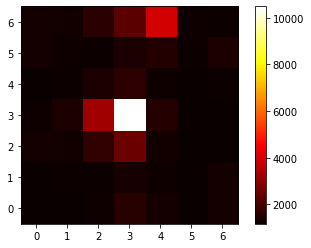

In [15]:
plt.imshow(imagette, interpolation='nearest', origin='lower', cmap=cm.hot)
plt.colorbar()

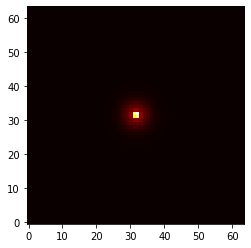

In [16]:
psf = simFile.getPsf("rebinnedPSFsubPixel")
plt.imshow(psf, interpolation='nearest', origin='lower', cmap=cm.hot)

In [17]:
starIDs, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = simFile.getStarCatalog()

In [18]:
"starIDs[{}] = {}".format(len(starIDs), starIDs)

'starIDs[1860] = [13164 13181 13200 ... 23926 23928 23932]'

In [19]:
print("RA[{}] = {}".format(len(RA), RA))
print("Dec[{}] = {}".format(len(dec), dec))
print("Vmag[{}] = {}".format(len(Vmag), Vmag))

RA[1860] = [178.7851   178.843447 178.918708 ... 179.916292 179.928872 179.939817]
Dec[1860] = [-70.004295 -70.007988 -70.007385 ... -69.595413 -69.595963 -69.598801]
Vmag[1860] = [14.856 12.866 13.58  ... 11.796 14.175 14.884]


In [20]:
print("xFPmm[{}] = {}".format(len(xFPmm), xFPmm))
print("yFPmm[{}] = {}".format(len(yFPmm), yFPmm))

xFPmm[1860] = [1.69447622e-02 1.03961456e-04 1.44295998e-03 ... 1.75077830e+00
 1.74786353e+00 1.73513462e+00]
yFPmm[1860] = [1.79492645 1.70890216 1.59770986 ... 0.07405642 0.0551836  0.03905758]


In [21]:
print("rowPix[{}] = {}".format(len(rowPix), rowPix))
print("colPix[{}] = {}".format(len(colPix), colPix))

rowPix[1860] = [99.71813618 94.93900886 88.76165908 ...  4.11424544  3.06575542
  2.16986573]
colPix[1860] = [9.41375678e-01 5.77563646e-03 8.01644432e-02 ... 9.72654610e+01
 9.71035294e+01 9.63963678e+01]


To get the coordinates of all stars within a magnitude range [minVmag, maxVmag] in image 10.

In [22]:
starID, row, col, Xmm, Ymm, flux = simFile.getStarCoordinates(9, minVmag=6.0, maxVmag=12.0)

In [23]:
"starID[{}] = {}".format(len(starID), starID)

'starID[171] = [13209 15191 15196 15208 15215 15223 15224 15235 15255 15271 15276 15285\n 15297 15299 15304 15334 15355 15356 15363 15370 15376 15380 15381 15382\n 15383 15393 15397 15400 15414 15428 15471 15486 15495 15515 15519 15525\n 15533 15538 15543 15553 15562 15563 15572 15574 15575 15596 15619 15636\n 15651 17330 17337 17342 17348 17353 17355 17359 17367 17387 17406 17411\n 17422 17436 17479 17483 17489 17497 17504 17521 17531 17546 17548 17556\n 17565 17566 17577 17583 17590 17607 17614 17623 17641 17656 17708 17713\n 17726 17741 17748 19409 19415 19416 19421 19451 19453 19458 19470 19476\n 19485 19496 19497 19507 19518 19540 19547 19553 19563 19564 19567 19573\n 19587 19613 19619 19638 19654 19686 19692 19700 19711 19713 19729 19731\n 19751 19761 19772 19796 19803 19805 19810 19811 19816 19827 19830 19831\n 21434 21436 21437 21452 21463 21486 21489 21500 21519 21535 21549 21554\n 21592 21626 21627 21638 21647 21659 21686 21724 21728 21736 21763 21776\n 21839 21856 21861 2186

In [24]:
simFile.getInputParameter("ObservingParameters", "NumExposures")

10

In [25]:
#%matplotlib qt
#%run -i setupMatplotlib.py

%matplotlib inline
%run -i setupMatplotlib.py

In [26]:
#fig = simFile.showImage(9)
#ID, row, col, Xmm, Ymm = simFile.getStarCoordinates(9)

#axis = fig.axes[0]
#axis.scatter(np.floor(col), np.floor(row), marker='x', c='g')

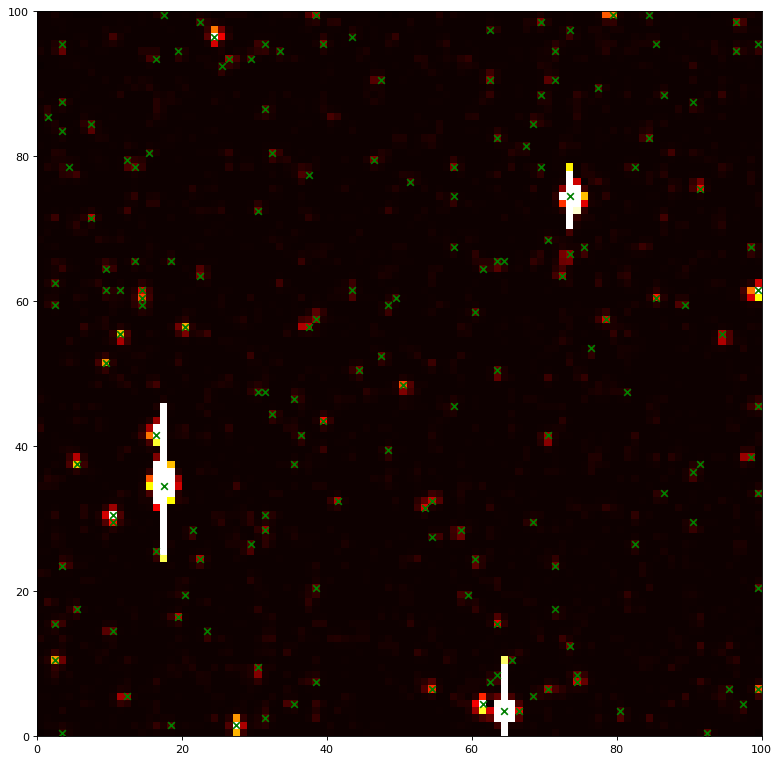

In [27]:
fig, ax = plt.subplots()
image = simFile.getImage(9)
numRows = simFile.getInputParameter("SubField", "NumRows")
numColumns = simFile.getInputParameter("SubField", "NumColumns")
ax.imshow(image, cmap=cm.hot, interpolation="nearest", origin='lower', extent=[0, numRows, 0, numColumns])
ax.scatter(np.floor(col)+0.5, np.floor(row)+0.5, marker='x', c='g')

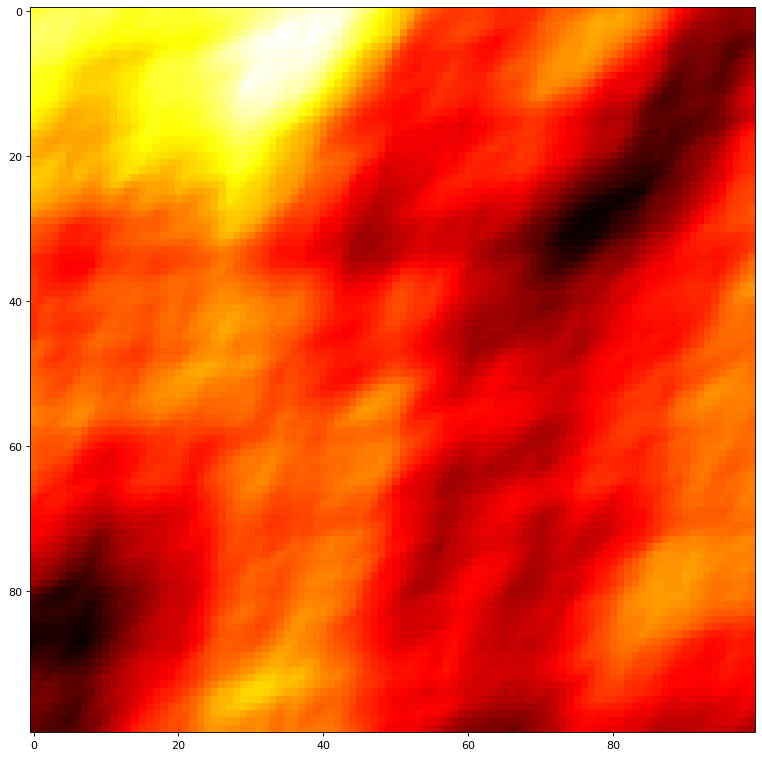

In [28]:
prnu = simFile.getPRNU()
plt.imshow(prnu, interpolation='nearest', cmap=cm.hot)

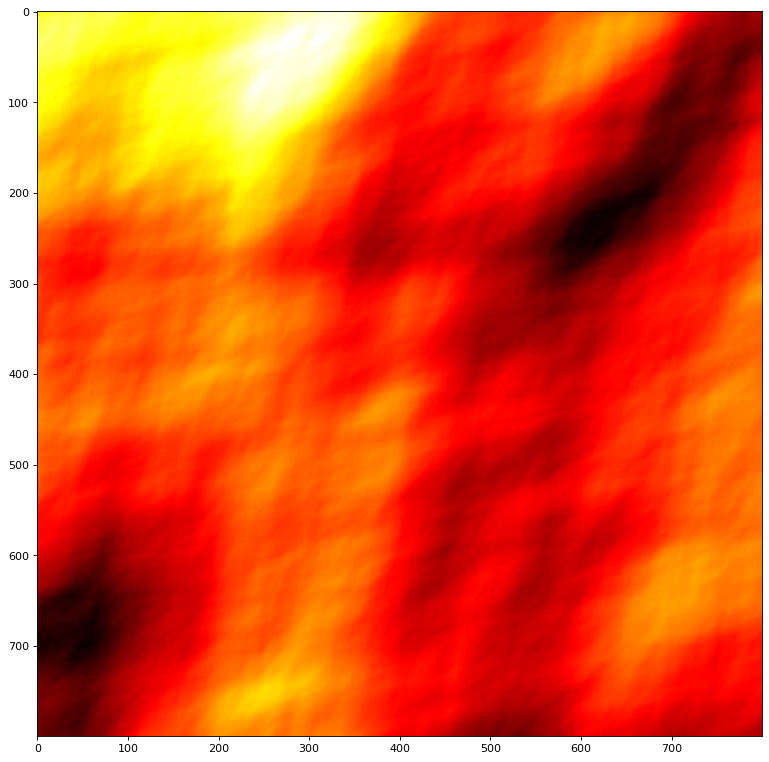

In [29]:
irnu = simFile.getIRNU()
plt.imshow(irnu, interpolation='nearest', cmap=cm.hot)

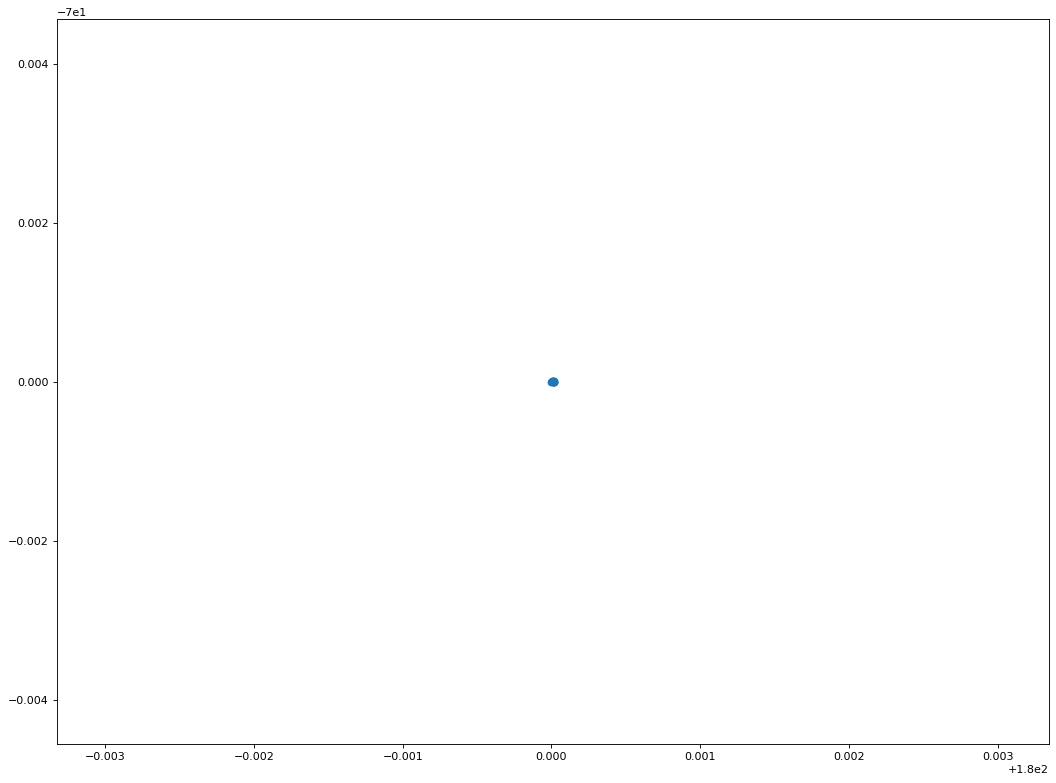

In [30]:
RA, dec = simFile.getPlatformPointingCoordinates()
plt.scatter(RA, dec)

In [31]:
yaw, pitch, roll = simFile.getYawPitchRoll()

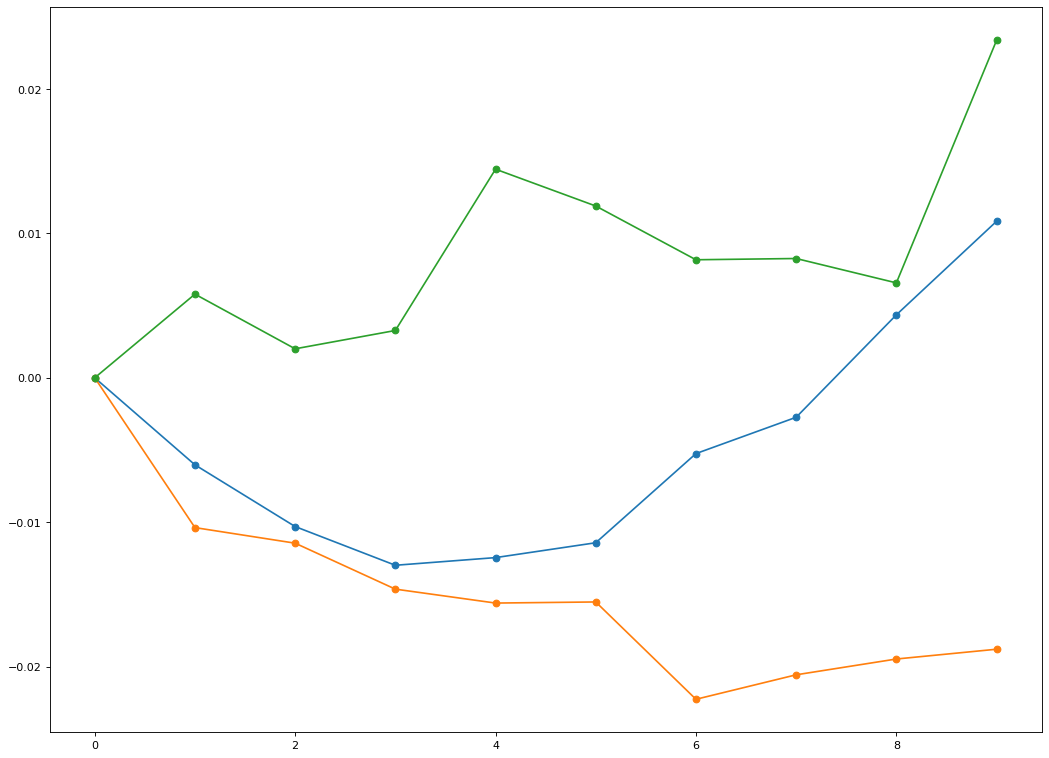

In [32]:
plt.plot(yaw, '-o')
plt.plot(pitch, '-o')
plt.plot(roll, '-o')